# Do insiders and institutions agree?

Cross two datasets: insider net buying (Forms 4) against the change in
institutional ownership (13F, quarter over quarter) for a basket of large
caps. The cusip that joins them comes from a third family, beneficial
ownership filings.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import re

import pandas as pd

from py3spread import Client

client = Client()

TICKERS = ["AAPL", "TSLA", "META", "AMZN", "GOOGL", "JPM", "KO", "GE", "XOM"]
Q_PREV, Q_LAST = "2025-12-31", "2026-03-31"
MIN_POSITION = 500_000_000  # only count large holders, keeps the pull quick


def cusip_for(ticker):
    # issuer_cusip on 13D/G is raw filing text ("30303M 102",
    # "Class B Common Stock: 02079K 206"), so normalize before joining
    rows = client.beneficial_ownership.list(ticker=ticker, limit=1)["data"]
    if not rows or not rows[0].get("issuer_cusip"):
        return None
    s = re.sub(r"[^0-9A-Za-z]", "", rows[0]["issuer_cusip"].split(":")[-1])
    return s[-9:].upper() if len(s) >= 9 else None


def institutional_shares(cusip, period):
    total = 0.0
    for h in client.institutional_holdings.iter_holdings(
        cusip=cusip, period=period, min_value=MIN_POSITION,
    ):
        total += float(h["ssh_prnamt"])
    return total


records = []
for ticker in TICKERS:
    cusip = cusip_for(ticker)
    prev = institutional_shares(cusip, Q_PREV) if cusip else 0
    if not prev:
        # the latest 13D/G may reference a different security (another
        # share class, or a filing the company made about someone else),
        # so verify the join resolved before trusting it
        print(f"{ticker}: cusip did not resolve to 13F holdings, skipping")
        continue
    last = institutional_shares(cusip, Q_LAST)
    ratio = client.insiders.buy_sell_ratio(ticker=ticker, window_days=180)
    records.append({
        "ticker": ticker,
        "inst_change_pct": (last - prev) / prev * 100,
        "insider_net_musd": (float(ratio["buys_dollars"]) - float(ratio["sells_dollars"])) / 1e6,
    })

df = pd.DataFrame(records)
df

GOOGL: cusip did not resolve to 13F holdings, skipping


XOM: cusip did not resolve to 13F holdings, skipping


,ticker,inst_change_pct,insider_net_musd
0,AAPL,-4.847177,-290.019103
1,TSLA,-6.925633,-59.844055
2,META,-3.041317,-343.168489
3,AMZN,-2.917465,-106.206982
4,JPM,-4.804877,-617.453371
5,KO,1.365165,-234.048098
6,GE,-5.951538,-183.225459


`inst_change_pct` is the change in shares held by managers with positions
over $500M. `insider_net_musd` is insider buys minus sells over the
trailing 180 days, in millions. Skipped tickers are the honest part of
working with SEC data: always verify a cross-dataset join actually
resolved instead of trusting the identifier.

Two different issues show up in that first cell, and they age differently:

- the cusip formatting quirk (embedded spaces, label prefixes) is fully
  handled by the normalization in `cusip_for` above, and the 3spread team
  is tracking a fix to serve clean cusips at the row level, at which point
  the cleanup becomes a harmless no-op
- the skipped tickers are a semantic mismatch: their latest 13D/G
  references a different share class or a different issuer entirely, which
  no string cleaning can resolve, hence verify-then-skip


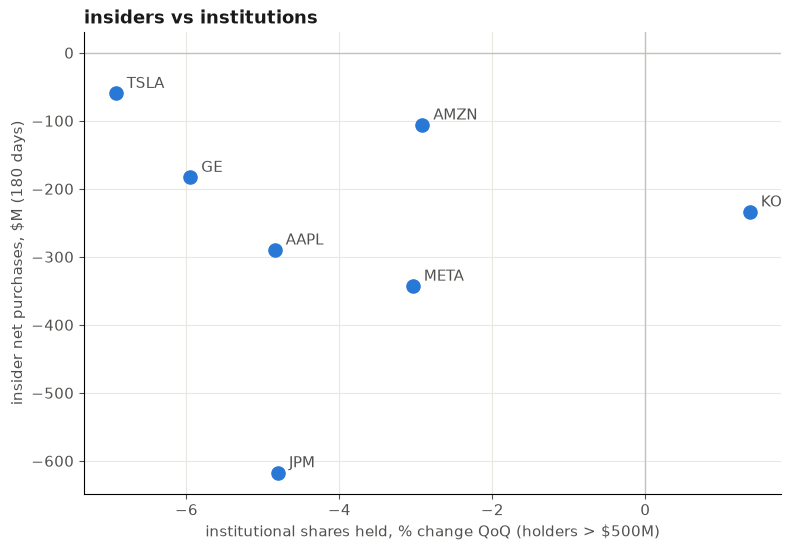

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
AQUA = "#1baf7a"
INK = "#52514e"


fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.scatter(df["inst_change_pct"], df["insider_net_musd"], s=90, color=BLUE, zorder=3)
for _, row in df.iterrows():
    ax.annotate(row["ticker"], (row["inst_change_pct"], row["insider_net_musd"]),
                xytext=(8, 4), textcoords="offset points", color=INK)
ax.set_xlabel("institutional shares held, % change QoQ (holders > $500M)")
ax.set_ylabel("insider net purchases, $M (180 days)")
ax.set_title("insiders vs institutions", loc="left", fontweight="bold")
plt.show()

Bottom left: both selling. Top right: both accumulating. The off-diagonal
quadrants are where the two groups disagree, which is where the
interesting questions start.

Caveats worth taking seriously before using this for anything real:

- the $500M floor means holders drifting across the threshold move the
  number without trading
- insiders sell for plenty of non-signal reasons (10b5-1 plans, taxes)
- 13F positions are reported with a 45 day lag

Widen `TICKERS`, drop `MIN_POSITION`, or extend the insider window to
turn this sketch into a study.